In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [8]:
words = open('./data/names.txt', mode='r').read().splitlines()

In [9]:
chars = list(sorted(set(''.join(words))))
stoi = {k:v+1 for v, k in enumerate(chars)}
stoi['.'] = 0
itos = {k:v for v,k in stoi.items()}

In [10]:
block_size = 3
X, Y = [], []
def build_dataset(words):
    for w in words:
        context = [0] * 3
        chs = w + '.'
        for i in chs:
            ix = stoi[i]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)
import numpy as np
np.random.seed(42)
words = np.random.permutation(words)

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [12]:
print(Xtr.shape)

torch.Size([182671, 3])


In [13]:
nembd = 10
n_hidden = 200

g = torch.Generator().manual_seed(0)
C = torch.randn((27, nembd), generator=g)
W1 = torch.randn((nembd * block_size, n_hidden), generator = g) * 0.1
b1 = torch.randn(size=(n_hidden,), generator=g) * 0.01
W2 = torch.randn((n_hidden, 27), generator = g) * 0.01
b2 = torch.randn(size=(27,), generator=g)* 0

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True
    

In [16]:
C,C.shape

(tensor([[-1.1258e+00, -1.1524e+00, -2.5058e-01, -4.3388e-01,  8.4871e-01,
           6.9201e-01, -3.1601e-01, -2.1152e+00,  3.2227e-01, -1.2633e+00],
         [ 3.4998e-01,  3.0813e-01,  1.1984e-01,  1.2377e+00,  1.1168e+00,
          -2.4728e-01, -1.3527e+00, -1.6959e+00,  5.6665e-01,  7.9351e-01],
         [ 5.9884e-01, -1.5551e+00, -3.4136e-01,  1.8530e+00,  7.5019e-01,
          -5.8550e-01, -1.7340e-01,  1.8348e-01,  1.3894e+00,  1.5863e+00],
         [ 9.4630e-01, -8.4368e-01, -6.1358e-01,  3.1593e-02, -4.9268e-01,
           2.4841e-01,  4.3970e-01,  1.1241e-01,  6.4079e-01,  4.4116e-01],
         [-1.0231e-01,  7.9244e-01, -2.8967e-01,  5.2507e-02,  5.2286e-01,
           2.3022e+00, -1.4689e+00, -1.5867e+00, -6.7309e-01,  8.7283e-01],
         [ 1.0554e+00,  1.7784e-01, -2.3034e-01, -3.9175e-01,  5.4329e-01,
          -3.9516e-01, -4.4622e-01,  7.4402e-01,  1.5210e+00,  3.4105e+00],
         [-1.5312e+00, -1.2341e+00,  1.8197e+00, -5.5153e-01, -5.6925e-01,
           9.1997e-

In [ ]:
C[Xtr[:32]].shape

tensor([[[-1.1258e+00, -1.1524e+00, -2.5058e-01, -4.3388e-01,  8.4871e-01,
           6.9201e-01, -3.1601e-01, -2.1152e+00,  3.2227e-01, -1.2633e+00],
         [-1.1258e+00, -1.1524e+00, -2.5058e-01, -4.3388e-01,  8.4871e-01,
           6.9201e-01, -3.1601e-01, -2.1152e+00,  3.2227e-01, -1.2633e+00],
         [-1.1258e+00, -1.1524e+00, -2.5058e-01, -4.3388e-01,  8.4871e-01,
           6.9201e-01, -3.1601e-01, -2.1152e+00,  3.2227e-01, -1.2633e+00]],

        [[-1.1258e+00, -1.1524e+00, -2.5058e-01, -4.3388e-01,  8.4871e-01,
           6.9201e-01, -3.1601e-01, -2.1152e+00,  3.2227e-01, -1.2633e+00],
         [-1.1258e+00, -1.1524e+00, -2.5058e-01, -4.3388e-01,  8.4871e-01,
           6.9201e-01, -3.1601e-01, -2.1152e+00,  3.2227e-01, -1.2633e+00],
         [-2.6133e+00, -1.6965e+00, -2.2824e-01,  2.7995e-01,  2.4693e-01,
           7.6887e-02,  3.3801e-01,  4.5440e-01,  4.5694e-01, -8.6537e-01]],

        [[-1.1258e+00, -1.1524e+00, -2.5058e-01, -4.3388e-01,  8.4871e-01,
           6.92

In [6]:
max_iter = 200000
batch_size = 32
for epoch in range(max_iter):
    ix = torch.randint(low=0, high=len(Xtr), size=(batch_size, ), generator= g)
    X, y = Xtr[ix], Ytr[ix]
    emb = C[X]
    embcat = emb.view(emb.size(0),-1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    
    loss = F.cross_entropy(logits, y)

    for p in params:
        p.grad = None
    
    loss.backward()

    lr = 0.1 if epoch <= 100000 else 0.01
    for p in params:
        p.data -= lr * p.grad

    if epoch % 100 ==0:
        print(f'{loss.item()}, learning_rate: {lr}')
    

3.310530185699463, learning_rate: 0.1
2.500338315963745, learning_rate: 0.1
2.726611375808716, learning_rate: 0.1
2.5514841079711914, learning_rate: 0.1
2.5416007041931152, learning_rate: 0.1
2.5369465351104736, learning_rate: 0.1
2.589751720428467, learning_rate: 0.1
2.5737345218658447, learning_rate: 0.1
2.257371425628662, learning_rate: 0.1
2.4190101623535156, learning_rate: 0.1
2.5616893768310547, learning_rate: 0.1
2.475454092025757, learning_rate: 0.1
2.3013453483581543, learning_rate: 0.1
2.118222951889038, learning_rate: 0.1
1.8983359336853027, learning_rate: 0.1
3.097822904586792, learning_rate: 0.1
2.44201397895813, learning_rate: 0.1
2.3968143463134766, learning_rate: 0.1
2.658208131790161, learning_rate: 0.1
2.478583574295044, learning_rate: 0.1
2.6838982105255127, learning_rate: 0.1
2.540731191635132, learning_rate: 0.1
3.0026090145111084, learning_rate: 0.1
2.446384906768799, learning_rate: 0.1
2.818758249282837, learning_rate: 0.1
2.3184595108032227, learning_rate: 0.1
2

KeyboardInterrupt: 

(array([ 35., 165., 210., 258., 346., 369., 416., 423., 456., 517., 504.,
        476., 463., 412., 379., 354., 248., 213., 122.,  34.]),
 array([-0.95614141, -0.85995185, -0.76376228, -0.66757272, -0.57138315,
        -0.47519359, -0.37900403, -0.28281446, -0.1866249 , -0.09043533,
         0.00575423,  0.1019438 ,  0.19813336,  0.29432293,  0.39051249,
         0.48670205,  0.58289162,  0.67908118,  0.77527075,  0.87146031,
         0.96764988]),
 <BarContainer object of 20 artists>)

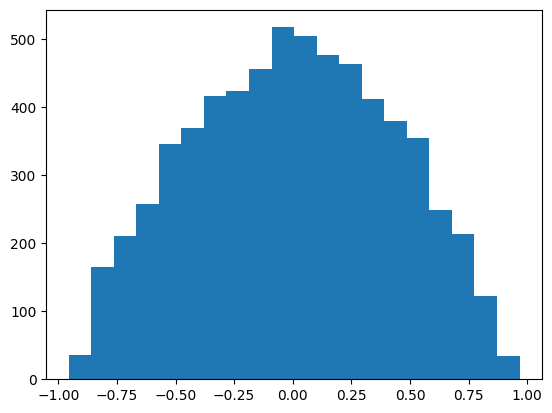

In [ ]:
# plt.hist(h.view(-1).detach().tolist(), bins=20)

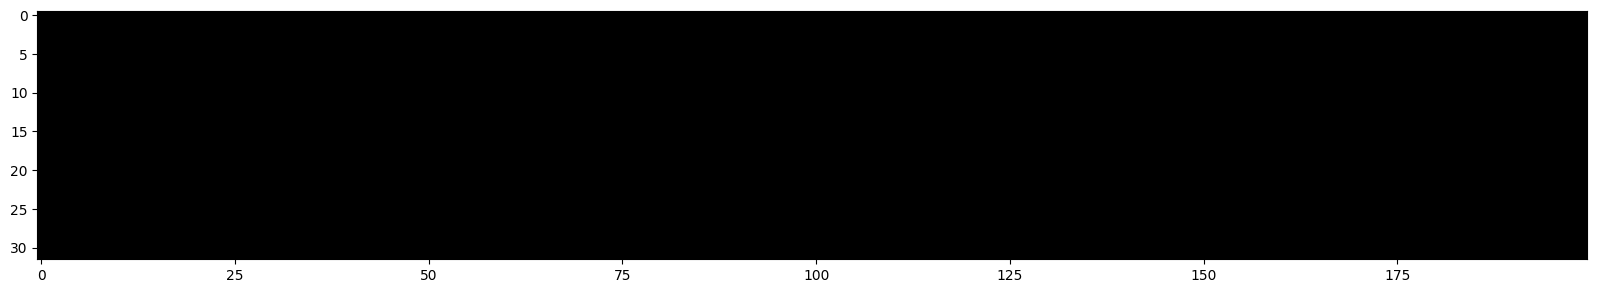

In [ ]:
# plt.figure(figsize=(20,10))
# plt.imshow(h.abs() > 0.99, cmap='grey', interpolation= 'nearest') ### 200代表两百个神经元 如果有一列是完全的白色 说明这一批数据完全没有更新该神经元的梯度y梯度


In [ ]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    emb = C[x]
    embcat = emb.view(emb.size(0), -1)
    embcat = emb.view(emb.size(0),-1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
split_loss('test')
split_loss('dev')

test 2.0730557441711426
dev 2.0675222873687744


In [ ]:
context = [0] *3
torch.tensor([context]).shape
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [ ]:
g = torch.Generator().manual_seed(1)
for _ in range(20):
    out = []
    context = [0] * 3
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(emb.size(0), -1)
        embcat = emb.view(emb.size(0), -1)
        embcat = emb.view(emb.size(0),-1)
        hpreact = embcat @ W1 + b1
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2 # （1，27）
        prob = F.softmax(logits, dim=1) ### (1,27)
        ix = torch.multinomial(prob, num_samples=1, generator=g).item() # 数字
        # print(ix)
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    # print(out)
    print(''.join(itos[i] for i in out))

ana.
ele.
lia.
aldi.
jaroreslynn.
abdulreti.
ritleightan.
madlain.
honera.
dacelianon.
alpeyshaus.
mairo.
tyson.
raiza.
tyel.
arie.
gracer.
khabnaranda.
samilus.
kelee.


tensor(-0.0160) tensor(1.0076)
tensor(-0.0240) tensor(0.5678)


(array([4.57508064e-05, 0.00000000e+00, 0.00000000e+00, 1.83003226e-04,
        2.74504839e-04, 9.15016128e-04, 1.37252419e-03, 3.06530403e-03,
        6.49661451e-03, 9.79067257e-03, 1.64702903e-02, 2.44309306e-02,
        3.87966838e-02, 5.74630129e-02, 8.50049983e-02, 1.17442320e-01,
        1.53127949e-01, 2.07708661e-01, 2.72949311e-01, 3.48941401e-01,
        4.24979241e-01, 5.11356763e-01, 5.88538374e-01, 6.71164330e-01,
        7.28261337e-01, 7.39516035e-01, 7.18104658e-01, 6.56020813e-01,
        5.97734286e-01, 5.04677146e-01, 4.21456429e-01, 3.40706255e-01,
        2.63387393e-01, 2.09721697e-01, 1.41827500e-01, 9.88674927e-02,
        7.25150282e-02, 4.80383467e-02, 3.06530403e-02, 1.72480540e-02,
        9.24166290e-03, 5.67310000e-03, 3.01955322e-03, 1.83003226e-03,
        6.40511290e-04, 3.66006451e-04, 9.15016128e-05, 0.00000000e+00,
        0.00000000e+00, 4.57508064e-05]),
 array([-2.79662347, -2.68733578, -2.57804809, -2.4687604 , -2.3594727 ,
        -2.25018501, 

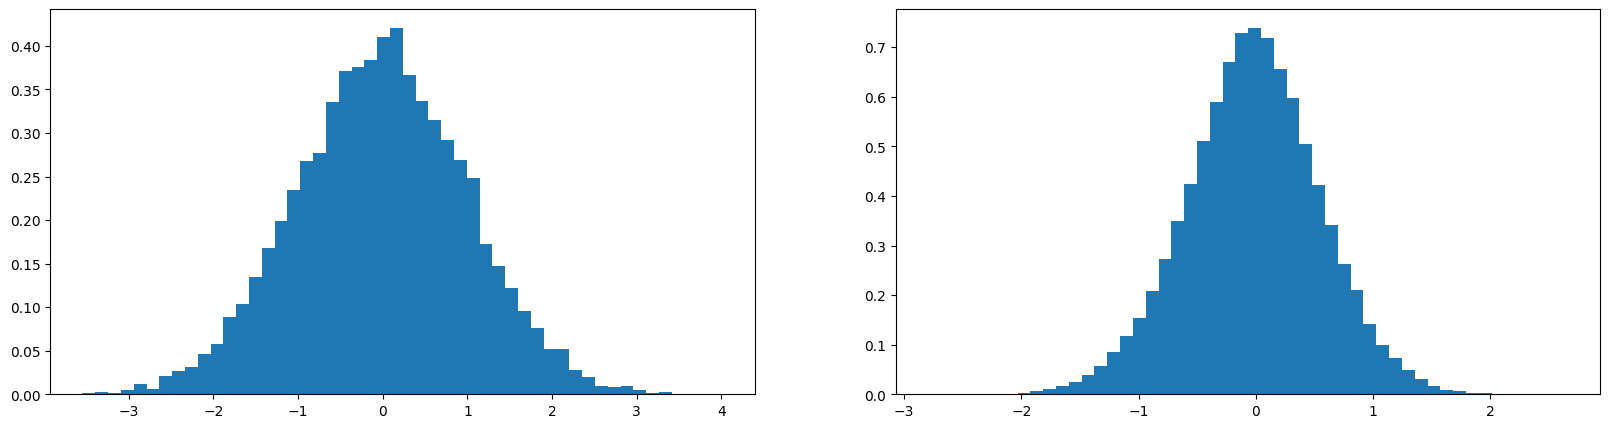

In [ ]:
x = torch.randn(size=[1000,10])
w = torch.rand(size = [10,200]) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(1,2,2)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [ ]:
### Batch Normalization
nembd = 10
n_hidden = 200

g = torch.Generator().manual_seed(1)
C = torch.randn((27, nembd), generator=g)
W1 = torch.randn((nembd * block_size, n_hidden), generator = g) * 0.1
b1 = torch.randn(size=(n_hidden,), generator=g) * 0.01
W2 = torch.randn((n_hidden, 27), generator = g) * 0.01
b2 = torch.randn(size=(27,), generator=g)* 0
slope = torch.randn(size=(1,n_hidden))
bias = torch.randn(size=(1,n_hidden))

params = [C, W1, b1, W2, b2, slope, bias]
for p in params:
    p.requires_grad = True

max_iter = 200000
batch_size = 32
for epoch in range(max_iter):
    ix = torch.randint(low=0, high=len(Xtr), size=(batch_size, ), generator= g)
    X, y = Xtr[ix], Ytr[ix]
    emb = C[X]
    embcat = emb.view(emb.size(0),-1)
    hpreact = embcat @ W1 + b1 ### batch_size, 200
    mean_var = hpreact.mean(dim=0, keepdim= True)
    std_var =  hpreact.std(dim=0, keepdim=True)
    hpreact = slope * ((hpreact - mean_var) / std_var) + bias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    
    loss = F.cross_entropy(logits, y)

    for p in params:
        p.grad = None
    
    loss.backward()

    lr = 0.1 if epoch <= 100000 else 0.01
    for p in params:
        p.data -= lr * p.grad

    if epoch % 100 ==0:
        print(f'{loss.item()}, learning_rate: {lr}')

3.252695083618164, learning_rate: 0.1
2.5122716426849365, learning_rate: 0.1
2.638035297393799, learning_rate: 0.1
2.3960859775543213, learning_rate: 0.1
2.4289772510528564, learning_rate: 0.1
2.1459906101226807, learning_rate: 0.1
2.6930105686187744, learning_rate: 0.1
2.644179344177246, learning_rate: 0.1
2.471811294555664, learning_rate: 0.1
2.079446792602539, learning_rate: 0.1
2.25346040725708, learning_rate: 0.1
2.2595937252044678, learning_rate: 0.1
2.3665223121643066, learning_rate: 0.1
2.2731823921203613, learning_rate: 0.1
2.5351552963256836, learning_rate: 0.1
2.633718490600586, learning_rate: 0.1
2.522718906402588, learning_rate: 0.1
2.40679669380188, learning_rate: 0.1
1.9731703996658325, learning_rate: 0.1
2.796956777572632, learning_rate: 0.1
2.574561357498169, learning_rate: 0.1
2.3122384548187256, learning_rate: 0.1
2.5062899589538574, learning_rate: 0.1
2.3401567935943604, learning_rate: 0.1
2.415365695953369, learning_rate: 0.1
2.3587465286254883, learning_rate: 0.1


In [ ]:
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.size(0),-1)
    hpreact = embcat @ W1 + b1 ### batch_size, 200
    bnmean = hpreact.mean(dim=0, keepdim=True)
    bnstd = hpreact.std(dim= 0, keepdim= True)
    

In [ ]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    emb = C[x]
    embcat = emb.view(emb.size(0), -1)
    embcat = emb.view(emb.size(0),-1)
    hpreact = embcat @ W1 + b1
    hpreact = slope * ((hpreact - bnmean) / bnstd) + bias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
split_loss('test')
split_loss('dev')

test 2.7136967182159424
dev 2.7112276554107666


In [ ]:
### Batch Normalization
nembd = 10
n_hidden = 200

g = torch.Generator().manual_seed(1)
C = torch.randn((27, nembd), generator=g)
W1 = torch.randn((nembd * block_size, n_hidden), generator = g) * 0.1
b1 = torch.randn(size=(n_hidden,), generator=g) * 0.01
W2 = torch.randn((n_hidden, 27), generator = g) * 0.01
b2 = torch.randn(size=(27,), generator=g)* 0
mean_ing = torch.ones(size = [1,n_hidden])
std_ing = torch.zeros(size=[1,n_hidden])
slope = torch.randn(size=(1,n_hidden))
bias = torch.randn(size=(1,n_hidden))

params = [C, W1, b1, W2, b2, slope, bias]
for p in params:
    p.requires_grad = True

max_iter = 200000
batch_size = 32
for epoch in range(max_iter):
    ix = torch.randint(low=0, high=len(Xtr), size=(batch_size, ), generator= g)
    X, y = Xtr[ix], Ytr[ix]
    emb = C[X]
    embcat = emb.view(emb.size(0),-1)
    hpreact = embcat @ W1 + b1 ### batch_size, 200
    mean_vari = hpreact.mean(dim=0, keepdim= True)
    std_vari =  hpreact.std(dim=0, keepdim=True)
    hpreact = slope * ((hpreact - mean_vari) / std_vari) + bias
    with torch.no_grad():
        mean_ing = 0.999 * mean_ing + 0.001 * mean_vari
        std_ing =0.999 * std_ing + 0.001 * std_vari
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    
    loss = F.cross_entropy(logits, y)

    for p in params:
        p.grad = None
    
    loss.backward()

    lr = 0.1 if epoch <= 100000 else 0.01
    for p in params:
        p.data -= lr * p.grad

    if epoch % 100 ==0:
        print(f'{loss.item()}, learning_rate: {lr}')

3.2959582805633545, learning_rate: 0.1
2.5105721950531006, learning_rate: 0.1
2.646533250808716, learning_rate: 0.1
2.3879079818725586, learning_rate: 0.1
2.412781238555908, learning_rate: 0.1
2.2035484313964844, learning_rate: 0.1
2.5855257511138916, learning_rate: 0.1
2.674954652786255, learning_rate: 0.1
2.515746593475342, learning_rate: 0.1
2.075749635696411, learning_rate: 0.1
2.2043886184692383, learning_rate: 0.1
2.219763994216919, learning_rate: 0.1
2.4313957691192627, learning_rate: 0.1
2.3434641361236572, learning_rate: 0.1
2.516695976257324, learning_rate: 0.1
2.626199960708618, learning_rate: 0.1
2.518404006958008, learning_rate: 0.1
2.491570234298706, learning_rate: 0.1
2.026719808578491, learning_rate: 0.1
2.8180503845214844, learning_rate: 0.1
2.5859649181365967, learning_rate: 0.1
2.2569386959075928, learning_rate: 0.1
2.457510232925415, learning_rate: 0.1
2.3110992908477783, learning_rate: 0.1
2.5392210483551025, learning_rate: 0.1
2.249650478363037, learning_rate: 0.1

In [ ]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    emb = C[x]
    embcat = emb.view(emb.size(0), -1)
    hpreact = embcat @ W1 + b1
    hpreact = slope * ((hpreact - mean_ing) / std_ing) + bias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
split_loss('test')
split_loss('dev')
split_loss('train')

test 2.099439859390259
dev 2.0960044860839844
train 2.0916149616241455
